<a href="https://colab.research.google.com/github/dhanushv282004/Ecommerce-Analysis/blob/main/E_commerce_Furniture.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**1- Project:** E-commerce Furniture Dataset 2024


**Project Objective**

1)Analyze furniture sales data

2)Predict item sales using price, title, and shipping infos

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

In [ ]:
import pandas as pd
df = pd.read_csv('/ecommerce_furniture_dataset_2024.csv')
df.head(5)

,productTitle,originalPrice,price,sold,tagText
0,Dresser For Bedroom With 9 Fabric Drawers Ward...,NaN,$46.79,600,Free shipping
1,Outdoor Conversation Set 4 Pieces Patio Furnit...,NaN,$169.72,0,Free shipping
2,Desser For Bedroom With 7 Fabric Drawers Organ...,$78.4,$39.46,7,Free shipping
3,"Modern Accent Boucle Chair,Upholstered Tufted ...",NaN,$111.99,0,Free shipping
4,Small Unit Simple Computer Desk Household Wood...,$48.82,$21.37,1,Free shipping


**Data Cleaning**

In [ ]:
# Remove rows with missing values
df = df.dropna()
# Clean price columns (remove '$', convert to float)
df['price'] = df['price'].replace(r'[\$,]', '', regex=True).astype(float)
df['originalPrice'] = df['originalPrice'].replace(r'[\$,]', '', regex=True).astype(float)

**Feature Engineering**

In [ ]:
# Calculate discount percentage
df['discount_percentage'] = ((df['originalPrice'] - df['price']) /df['originalPrice']) * 100

# Encode tagText
le = LabelEncoder()
df['tagText_encoded'] = le.fit_transform(df['tagText'])

# TF-IDF vectorization on product titles
tfidf = TfidfVectorizer(max_features=100)
tfidf_matrix = tfidf.fit_transform(df['productTitle'])
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(),
columns=tfidf.get_feature_names_out())

# Combine with original dataframe
df = pd.concat([df.reset_index(drop=True),
tfidf_df.reset_index(drop=True)], axis=1)

# Drop unused columns
df.drop(['productTitle', 'tagText', 'originalPrice'], axis=1,
inplace=True)


**Exploratory Data Analysis**

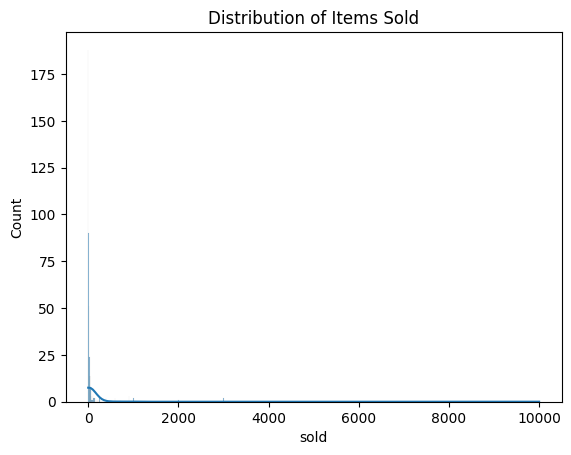

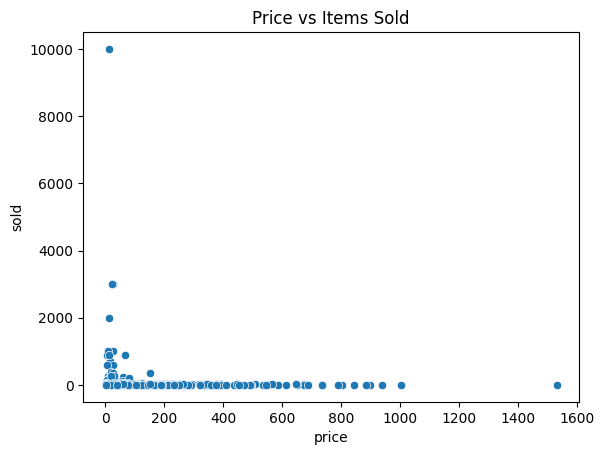

In [ ]:
sns.histplot(df['sold'], kde=True)
plt.title('Distribution of Items Sold')
plt.show()
sns.scatterplot(x='price', y='sold', data=df)
plt.title('Price vs Items Sold')
plt.show()


**Modeling**

In [ ]:
# Split features and target
X = df.drop('sold', axis=1)
y = df['sold']
X_train, X_test, y_train, y_test = train_test_split(X, y,
test_size=0.2, random_state=42)

# Train Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Train Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

**Evaluation**

In [ ]:
print("Linear Regression")
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("R²:", r2_score(y_test, y_pred_lr))
print("\nRandom Forest")
print("MSE:", mean_squared_error(y_test, y_pred_rf))
print("R²:", r2_score(y_test, y_pred_rf))


Linear Regression
MSE: 193541.74114057905
R²: -0.4062982753948845

Random Forest
MSE: 128279.42743367347
R²: 0.06790578349925402


**Conclusion**

1. TF-IDF + price + tagText were used as features
2. Random Forest performed better
3. Price and product text influence number of items sold